<a href="https://colab.research.google.com/github/JakeyV8/cs417-labs/blob/main/Lab10/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 10: Searching Analysis

Paste your completed search functions below, then work through the three experiments.

For each experiment: **run the code**, then **answer the questions** in the markdown cells.

In [9]:

# ── TODO 1: Sequential Search ────────────────────────────────────


def sequential_search(a_list, target):
    for item in a_list:
        if item == target:
            return (True,count)
    return False



# ── TODO 2: Binary Search ────────────────────────────────────────


def binary_search(a_list, target):
    first = 0
    last = len(a_list)-1
    while first <= last:
        mid = (first+last)//2
        if a_list[mid] == target:
            return True
        elif target < a_list[mid]:
            last = mid -1
        else:
            first = mid + 1
    return False


# ── TODO 3: Counted Versions ─────────────────────────────────────


def sequential_search_counted(a_list, target):
    count = 0
    for item in a_list:
        if item == target:
            return (True,count)
        count += 1
    return False


def binary_search_counted(a_list, target):
    first = 0
    count = 0
    last = len(a_list)-1
    while first <= last:
        mid = (first+last)//2
        if a_list[mid] == target:
            return (True, count)
        elif target < a_list[mid]:
            last = mid -1
        else:
            first = mid + 1
            count += 1
    return False



In [2]:
# Imports for the experiments
import random
import matplotlib.pyplot as plt

---
## Experiment 1: The Comparison Race

Run both counted searches on sorted lists of increasing size and plot the comparison counts.

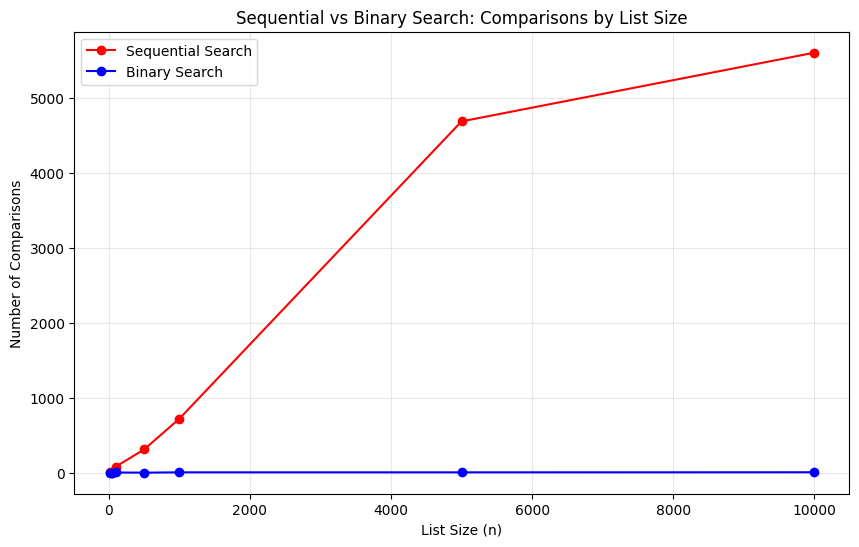

In [11]:
sizes = [10, 50, 100, 500, 1000, 5000, 10000]
seq_counts = []
bin_counts = []

for n in sizes:
    # Generate a sorted list of n items
    test_list = list(range(n))
    # Pick a random target (might or might not be in the list)
    target = random.randint(0, n)

    _, s_count = sequential_search_counted(test_list, target)
    _, b_count = binary_search_counted(test_list, target)

    seq_counts.append(s_count)
    bin_counts.append(b_count)

plt.figure(figsize=(10, 6))
plt.plot(sizes, seq_counts, 'o-', label='Sequential Search', color='red')
plt.plot(sizes, bin_counts, 'o-', label='Binary Search', color='blue')
plt.xlabel('List Size (n)')
plt.ylabel('Number of Comparisons')
plt.title('Sequential vs Binary Search: Comparisons by List Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Experiment 1 Questions

**Q1:** Describe the shape of each curve. Why does one grow so much faster than the other?

The Sequential curve was very linear. Yet the binary was a straight line at zero.


**Q2:** At what list size does the difference start to feel significant?

When the list starts growing to the thousands

---
## Experiment 2: Best Case, Worst Case

How much does performance vary depending on *where* the target is (or if it's there at all)?

In [20]:
n = 10000
test_list = list(range(n))

# Sequential search: best case vs worst case
_, seq_best = sequential_search_counted(test_list, test_list[0])      # first element
_, seq_worst = sequential_search_counted(test_list, n + 1)            # not in list

print("=== Sequential Search (n = 10,000) ===")
print(f"Best case  (first element):  {seq_best} comparisons")
print(f"Worst case (not in list):    {seq_worst} comparisons")
print()

# Binary search: does target position matter?
_, bin_first = binary_search_counted(test_list, test_list[0])         # first element
_, bin_last = binary_search_counted(test_list, test_list[-1])         # last element
_, bin_mid = binary_search_counted(test_list, test_list[n // 2])      # middle element
_, bin_miss = binary_search_counted(test_list, n + 1)                 # not in list

print("=== Binary Search (n = 10,000) ===")
print(f"First element:    {bin_first} comparisons")
print(f"Last element:     {bin_last} comparisons")
print(f"Middle element:   {bin_mid} comparisons")
print(f"Not in list:      {bin_miss} comparisons")

TypeError: cannot unpack non-iterable bool object

### Experiment 2 Questions

**Q3:** Why does sequential search have such a huge gap between best and worst case?

Sequantial search has a large gap because best case its found at exactly the first spot or its looping through n amount of times to get to the final spot.


**Q4:** Why is binary search so consistent regardless of where the target is? What about the algorithm causes this?

Binary search is so consistant because at most its doing it 10 times. The splitting in half of data set makes it so consistant.

---
## Experiment 3: When Is Sorting Worth It?

Binary search requires sorted data, and sorting costs O(n log n). If you have an unsorted list and need to search it *k* times, when does it pay to sort first?

**The two options:**
- **Option A:** Sequential search each time. Total cost: k × n
- **Option B:** Sort first (n log n), then binary search each time. Total cost: n log n + k × log n

### Q5: Calculate the crossover

For n = 10,000: set the two cost formulas equal and solve for *k*. Show your work.

k*10000 = 10,000log(10,000) + klog(10,000)
k = 4

In [19]:
import math

n = 10000
log_n = math.log2(n)  # approximately 13.3

# Try different values of k and compare total costs
print(f"n = {n}, log2(n) ≈ {log_n:.1f}")
print(f"{'k':>5}  {'Option A (k×n)':>15}  {'Option B (n·log n + k·log n)':>30}  {'Winner':>8}")
print("-" * 65)

for k in [1, 2, 5, 10, 13, 14, 15, 20, 50, 100]:
    cost_a = k * n
    cost_b = n * log_n + k * log_n
    winner = "A" if cost_a < cost_b else "B" if cost_b < cost_a else "Tie"
    print(f"{k:>5}  {cost_a:>15,.0f}  {cost_b:>30,.0f}  {winner:>8}")

n = 10000, log2(n) ≈ 13.3
    k   Option A (k×n)    Option B (n·log n + k·log n)    Winner
-----------------------------------------------------------------
    1           10,000                         132,890         A
    2           20,000                         132,904         A
    5           50,000                         132,944         A
   10          100,000                         133,010         A
   13          130,000                         133,050         A
   14          140,000                         133,063         B
   15          150,000                         133,076         B
   20          200,000                         133,143         B
   50          500,000                         133,542         B
  100        1,000,000                         134,206         B


### Experiment 3 Questions

**Q6:** Does the experimental crossover match your calculation? If not, why might they differ?

No my calculations dont match, I got 4 for my k yet the experimental value for an equaling k is around 13.


**Q7:** Give a real-world example where you'd choose Option A (just search without sorting) and one where you'd choose Option B (sort first, then search).

If your data is a one time use then searching with out sorting will save time because sorting is 0(n^2) but if your data set has multiple needs doing a sort will help.
